# Análisis de Telemetría de UAVs: Vuelos de Calibración del 2026-06-10
## Comparación de Variabilidad y Estabilidad Física (Real vs. Simulado)

Este notebook presenta un análisis comparativo de la telemetría de vuelos de drones reales frente a vuelos simulados en AirSim para la fecha **2026-06-10**. 

### Contexto de los Datos y Adaptación:
En esta fecha, a diferencia de los conjuntos de datos anteriores (por ejemplo, del 2026-04-13), se implementaron dos trayectorias de calibración distintas para cada uno de los drones:
1. **Dron 1 / Drone 1:** Sigue una trayectoria rectangular amplia y alargada definida en `calibration_path_20260610_drone1.txt`. Su telemetría simulada asociada corresponde a los archivos `telemetry_20260610_2205.csv`, `telemetry_20260610_2210.csv` y `telemetry_20260610_2215.csv`.
2. **Dron 2 / Drone 2:** Sigue una trayectoria cruz-rectangular compleja definida en `calibration_path_20260610_drone2.txt`. Su telemetría simulada asociada corresponde a los archivos `telemetry_20260610_2229.csv`, `telemetry_20260610_2235.csv` y `telemetry_20260610_2240.csv`.

Por lo tanto, realizamos las comparaciones físicas (ángulos de balance estimados, velocidades y variabilidad) de manera segregada para **Dron 1** y **Dron 2**, garantizando la validez científica y el rigor metodológico del análisis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy import stats
from scipy.signal import savgol_filter

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14


## 1. Definición de Funciones de Procesamiento y Estimación

Definiremos las funciones para:
- Convertir coordenadas GPS reales a coordenadas cartesianas planas locales (en metros).
- Calcular derivadas numéricas suavizadas de posición para obtener velocidad y aceleración (reduciendo el ruido del GPS).
- Estimar roll y pitch mediante la rotación de las aceleraciones al marco del cuerpo (Body Frame) y la aplicación de las ecuaciones dinámicas.


In [2]:
def latlon_to_local(df, lat_col='aircraftLatitude', lon_col='aircraftLongitude'):
    """Convierte coordenadas geográficas a metros locales usando proyección plana."""
    df = df.dropna(subset=[lat_col, lon_col]).copy()
    R = 6371000.0  # Radio de la Tierra en metros
    lat0 = df[lat_col].mean()
    lon0 = df[lon_col].mean()
    lat0_rad = np.radians(lat0)
    
    lat_rad = np.radians(df[lat_col])
    lon_rad = np.radians(df[lon_col])
    
    df['x_local'] = R * (lon_rad - np.radians(lon0)) * np.cos(lat0_rad)
    df['y_local'] = R * (lat_rad - np.radians(lat0))
    return df

def estimate_attitude(df, g=9.81):
    """Estima roll y pitch en base a aceleraciones en el marco del cuerpo (Body Frame)."""
    psi = df['heading']
    a_N = df['a_North']
    a_E = df['a_East']
    
    # Rotación de aceleración global a marco del dron (Body Frame)
    # Forward acceleration
    a_bf = a_N * np.cos(psi) + a_E * np.sin(psi)
    # Lateral (right) acceleration
    a_bl = -a_N * np.sin(psi) + a_E * np.cos(psi)
    
    df['a_forward'] = a_bf
    df['a_lateral'] = a_bl
    
    # Estimación de inclinaciones en grados
    df['est_pitch'] = -np.arctan2(a_bf, g) * 180.0 / np.pi
    df['est_roll'] = np.arctan2(a_bl, g) * 180.0 / np.pi
    return df

def process_real_drone(df):
    """Preprocesa la telemetría real: suavizado, cálculo de velocidad/aceleración y actitud."""
    df = latlon_to_local(df)
    
    # Mapeo de coordenadas (North = Y_local, East = X_local)
    df['North'] = df['y_local']
    df['East'] = df['x_local']
    df['Altitude'] = df['aircraftAltitude']
    
    # Ordenar y crear columna de tiempo en segundos
    df = df.sort_values(by='timestamp_ms').reset_index(drop=True)
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 1000.0
    
    # Eliminar duplicados temporales
    df['dt'] = df['time_s'].diff()
    df = df[df['dt'].isna() | (df['dt'] > 0)].reset_index(drop=True)
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 1000.0
    
    # Suavizado triple para amortiguar ruido de GPS en derivadas sucesivas
    n = len(df)
    window = min(15, n - (1 if n % 2 == 0 else 2))
    
    if window >= 5:
        df['N_smooth'] = savgol_filter(df['North'], window, 2)
        df['E_smooth'] = savgol_filter(df['East'], window, 2)
    else:
        df['N_smooth'] = df['North']
        df['E_smooth'] = df['East']
        
    df['v_North'] = np.gradient(df['N_smooth'], df['time_s'])
    df['v_East'] = np.gradient(df['E_smooth'], df['time_s'])
    
    if window >= 5:
        df['v_North'] = savgol_filter(df['v_North'], window, 2)
        df['v_East'] = savgol_filter(df['v_East'], window, 2)
        
    df['a_North'] = np.gradient(df['v_North'], df['time_s'])
    df['a_East'] = np.gradient(df['v_East'], df['time_s'])
    
    if window >= 5:
        df['a_North'] = savgol_filter(df['a_North'], window, 2)
        df['a_East'] = savgol_filter(df['a_East'], window, 2)
        
    # Rumbo en radianes (heading de 0 a 360 grados)
    df['heading'] = np.radians(df['headingDroneDegress'])
    
    df = estimate_attitude(df)
    
    # Tasa de giro (yaw rate)
    unwrapped = np.unwrap(df['heading'])
    df['yaw_rate'] = np.gradient(unwrapped, df['time_s'])
    df['yaw_rate_deg'] = np.degrees(df['yaw_rate'])
    
    return df

def process_simulated_file(filepath):
    """Preprocesa un archivo de telemetría simulada."""
    df = pd.read_csv(filepath)
    
    df['North'] = df['x']
    df['East'] = df['y']
    df['Altitude'] = -df['z']
    df['time_s'] = df['sim_t'] - df['sim_t'].iloc[0]
    
    # Calcular aceleraciones a partir de vx, vy provistas por AirSim
    df['a_North'] = np.gradient(df['vx'], df['time_s'])
    df['a_East'] = np.gradient(df['vy'], df['time_s'])
    
    # Suavizado leve para las aceleraciones
    n = len(df)
    window = min(11, n - (1 if n % 2 == 0 else 2))
    if window >= 5:
        df['a_North'] = savgol_filter(df['a_North'], window, 2)
        df['a_East'] = savgol_filter(df['a_East'], window, 2)
        
    df['heading'] = np.radians(df['yaw_deg'])
    
    df = estimate_attitude(df)
    
    unwrapped = np.unwrap(df['heading'])
    df['yaw_rate'] = np.gradient(unwrapped, df['time_s'])
    df['yaw_rate_deg'] = np.degrees(df['yaw_rate'])
    
    return df


## 2. Carga y Procesamiento de los Conjuntos de Datos

Cargaremos los datos reales (`consolidated_telemetry.csv`) para `drone1` y `drone2`.
Luego cargaremos de forma masiva los archivos de telemetría simulada para la fecha `20260610`, separándolos según el dron que representan:
- **Dron 1 Simulados:** `telemetry_20260610_2205.csv`, `telemetry_20260610_2210.csv`, y `telemetry_20260610_2215.csv`.
- **Dron 2 Simulados:** `telemetry_20260610_2229.csv`, `telemetry_20260610_2235.csv`, y `telemetry_20260610_2240.csv`.


In [3]:
# Carga de datos reales
real_path = os.path.join('actual_telemetry', 'consolidated_telemetry.csv')
df_real_raw = pd.read_csv(real_path)

df_d1_real = df_real_raw[df_real_raw['droneID'] == 'drone1'].copy()
df_d2_real = df_real_raw[df_real_raw['droneID'] == 'drone2'].copy()

print("Procesando telemetría real...")
df_d1_real_proc = process_real_drone(df_d1_real)
df_d2_real_proc = process_real_drone(df_d2_real)
print(f"Dron 1 (Real) - Filas procesadas: {df_d1_real_proc.shape[0]}")
print(f"Dron 2 (Real) - Filas procesadas: {df_d2_real_proc.shape[0]}")

# Archivos simulados de 20260610
sim_dir = 'simulated_telemetry/flights/20260610'
sim_files_d1 = [
    os.path.join(sim_dir, 'telemetry_20260610_2205.csv'),
    os.path.join(sim_dir, 'telemetry_20260610_2210.csv'),
    os.path.join(sim_dir, 'telemetry_20260610_2215.csv')
]
sim_files_d2 = [
    os.path.join(sim_dir, 'telemetry_20260610_2229.csv'),
    os.path.join(sim_dir, 'telemetry_20260610_2235.csv'),
    os.path.join(sim_dir, 'telemetry_20260610_2240.csv')
]

def load_sim_group(file_list, group_name):
    dfs = []
    for i, f in enumerate(file_list):
        if os.path.exists(f):
            df = process_simulated_file(f)
            df['flight_id'] = f"{group_name}_sim_{i+1}"
            dfs.append(df)
        else:
            print(f"Advertencia: Archivo no encontrado: {f}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print("\nCargando y procesando telemetría simulada...")
df_d1_sim_all = load_sim_group(sim_files_d1, 'drone1')
df_d2_sim_all = load_sim_group(sim_files_d2, 'drone2')

print(f"Dron 1 (Simulado) - Filas consolidadas: {df_d1_sim_all.shape[0]}")
print(f"Dron 2 (Simulado) - Filas consolidadas: {df_d2_sim_all.shape[0]}")


Procesando telemetría real...
Dron 1 (Real) - Filas procesadas: 329
Dron 2 (Real) - Filas procesadas: 456

Cargando y procesando telemetría simulada...
Dron 1 (Simulado) - Filas consolidadas: 8005
Dron 2 (Simulado) - Filas consolidadas: 8703


## 3. Segmentación de Vuelo: Rectas vs. Giros (Maniobras de Rumbo)

Para aislar el efecto de la inercia durante los cambios de dirección, calculamos la tasa de giro absoluta en grados por segundo (`abs_yaw_rate_deg`). 
Clasificamos los instantes en:
- **Giro (Turn):** Tasa de giro $> 5.0$ grados/segundo.
- **Recta (Straight):** Tasa de giro $\le 5.0$ grados/segundo.


In [4]:
threshold = 5.0  # umbral en deg/s

# Dron 1 Real
df_d1_real_proc['maneuver'] = np.where(df_d1_real_proc['yaw_rate_deg'].abs() > threshold, 'Giro', 'Recta')
# Dron 1 Simulado
df_d1_sim_all['maneuver'] = np.where(df_d1_sim_all['yaw_rate_deg'].abs() > threshold, 'Giro', 'Recta')

# Dron 2 Real
df_d2_real_proc['maneuver'] = np.where(df_d2_real_proc['yaw_rate_deg'].abs() > threshold, 'Giro', 'Recta')
# Dron 2 Simulado
df_d2_sim_all['maneuver'] = np.where(df_d2_sim_all['yaw_rate_deg'].abs() > threshold, 'Giro', 'Recta')

print("Distribución de maniobras para Dron 1:")
print("Real Drone 1:\n", df_d1_real_proc['maneuver'].value_counts())
print("Simulado Drone 1:\n", df_d1_sim_all['maneuver'].value_counts())

print("\nDistribución de maniobras para Dron 2:")
print("Real Drone 2:\n", df_d2_real_proc['maneuver'].value_counts())
print("Simulado Drone 2:\n", df_d2_sim_all['maneuver'].value_counts())


Distribución de maniobras para Dron 1:
Real Drone 1:
 maneuver
Recta    312
Giro      17
Name: count, dtype: int64
Simulado Drone 1:
 maneuver
Recta    7902
Giro      103
Name: count, dtype: int64

Distribución de maniobras para Dron 2:
Real Drone 2:
 maneuver
Recta    427
Giro      29
Name: count, dtype: int64
Simulado Drone 2:
 maneuver
Recta    8541
Giro      162
Name: count, dtype: int64


## 4. Distribuciones de Probabilidad de Gimbal (Real vs. Simulado)

Dado que no hay columnas directas de gimbal en la telemetría simulada, utilizaremos el promedio de la orientación física estimada (`est_pitch`, `est_roll`, `yaw_deg`) de los vuelos simulados como un proxy para comparar con los ángulos de gimbal registrados en el vuelo real.
Compararemos:
- **Dron 1:** Gimbal Real vs. Proxy Simulado (promedio de vuelos simulados del Dron 1).
- **Dron 2:** Gimbal Real vs. Proxy Simulado (promedio de vuelos simulados del Dron 2).


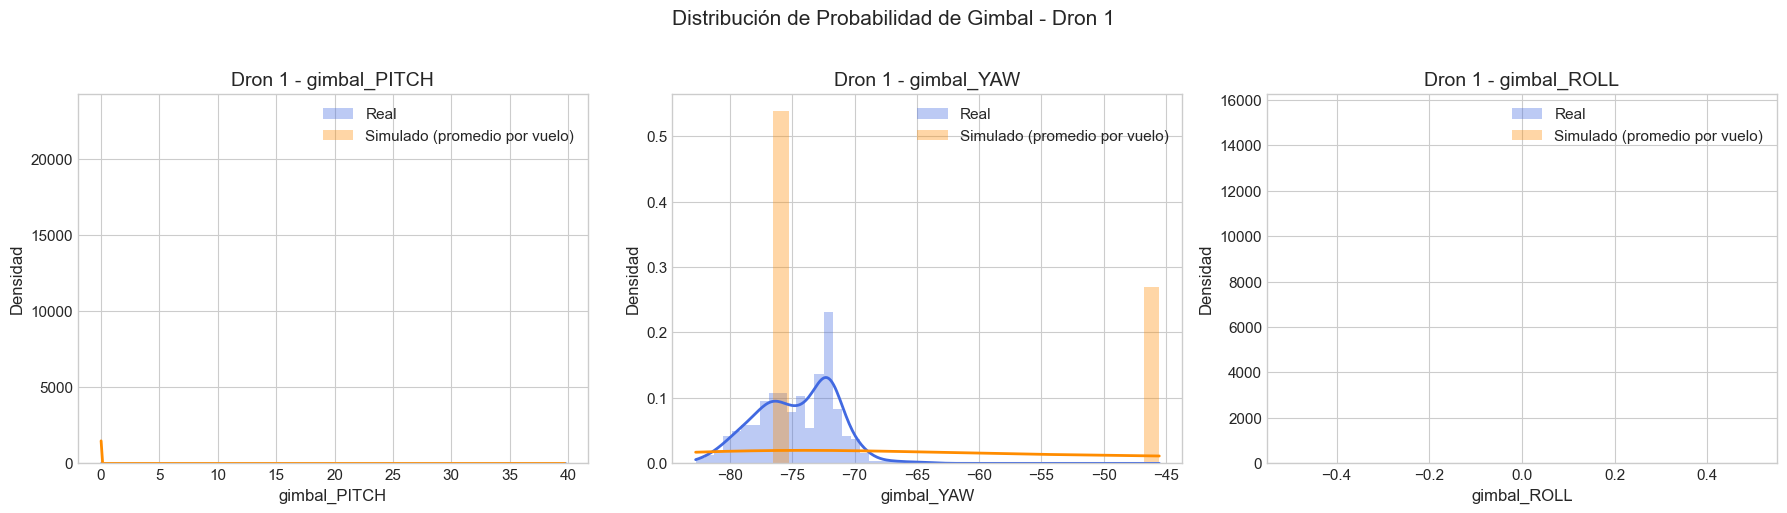

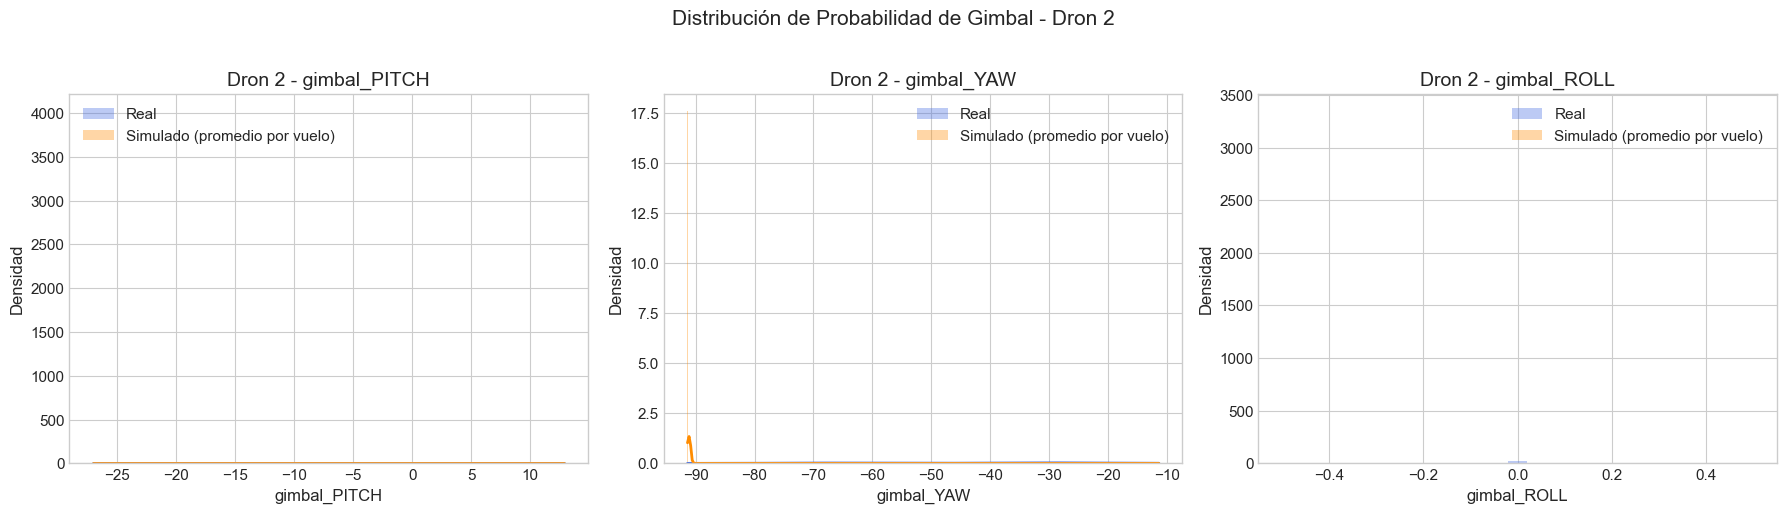

In [5]:
def _plot_dist(ax, real_values, sim_values, title, xlabel):
    real_values = pd.Series(real_values).dropna().astype(float)
    sim_values = pd.Series(sim_values).dropna().astype(float)

    ax.hist(real_values, bins=25, density=True, alpha=0.35, color='royalblue', label='Real')
    ax.hist(sim_values, bins=25, density=True, alpha=0.35, color='darkorange', label='Simulado (promedio por vuelo)')

    combined = pd.concat([real_values, sim_values], ignore_index=True)
    if len(combined) > 2 and combined.nunique() > 1:
        x_min, x_max = combined.min(), combined.max()
        x = np.linspace(x_min, x_max, 300)
        try:
            kde_real = stats.gaussian_kde(real_values)
            kde_sim = stats.gaussian_kde(sim_values)
            ax.plot(x, kde_real(x), color='royalblue', lw=2)
            ax.plot(x, kde_sim(x), color='darkorange', lw=2)
        except Exception:
            pass

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(True)

# Proxies de actitud promedio para simulados
df_d1_sim_proxy = (
    df_d1_sim_all.groupby('flight_id', as_index=False)
    .agg({'est_pitch': 'mean', 'est_roll': 'mean', 'yaw_deg': 'mean'})
    .rename(columns={'est_pitch': 'gimbal_PITCH', 'est_roll': 'gimbal_ROLL', 'yaw_deg': 'gimbal_YAW'})
)

df_d2_sim_proxy = (
    df_d2_sim_all.groupby('flight_id', as_index=False)
    .agg({'est_pitch': 'mean', 'est_roll': 'mean', 'yaw_deg': 'mean'})
    .rename(columns={'est_pitch': 'gimbal_PITCH', 'est_roll': 'gimbal_ROLL', 'yaw_deg': 'gimbal_YAW'})
)

# Plot Dron 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_plot_dist(axes[0], df_d1_real_proc['gimbal_PITCH'], df_d1_sim_proxy['gimbal_PITCH'], 'Dron 1 - gimbal_PITCH', 'gimbal_PITCH')
_plot_dist(axes[1], df_d1_real_proc['gimbal_YAW'], df_d1_sim_proxy['gimbal_YAW'], 'Dron 1 - gimbal_YAW', 'gimbal_YAW')
_plot_dist(axes[2], df_d1_real_proc['gimbal_ROLL'], df_d1_sim_proxy['gimbal_ROLL'], 'Dron 1 - gimbal_ROLL', 'gimbal_ROLL')
fig.suptitle('Distribución de Probabilidad de Gimbal - Dron 1', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Plot Dron 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_plot_dist(axes[0], df_d2_real_proc['gimbal_PITCH'], df_d2_sim_proxy['gimbal_PITCH'], 'Dron 2 - gimbal_PITCH', 'gimbal_PITCH')
_plot_dist(axes[1], df_d2_real_proc['gimbal_YAW'], df_d2_sim_proxy['gimbal_YAW'], 'Dron 2 - gimbal_YAW', 'gimbal_YAW')
_plot_dist(axes[2], df_d2_real_proc['gimbal_ROLL'], df_d2_sim_proxy['gimbal_ROLL'], 'Dron 2 - gimbal_ROLL', 'gimbal_ROLL')
fig.suptitle('Distribución de Probabilidad de Gimbal - Dron 2', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 5. Visualización de Trayectorias y Dinámica de Vuelo

Visualizaremos las trayectorias 2D (Norte vs. Este) de los vuelos reales y simulados.
Detectaremos los puntos de giro significativos usando cambios en el producto punto de la dirección de movimiento para verificar la correspondencia espacial y rotular las coordenadas en metros.


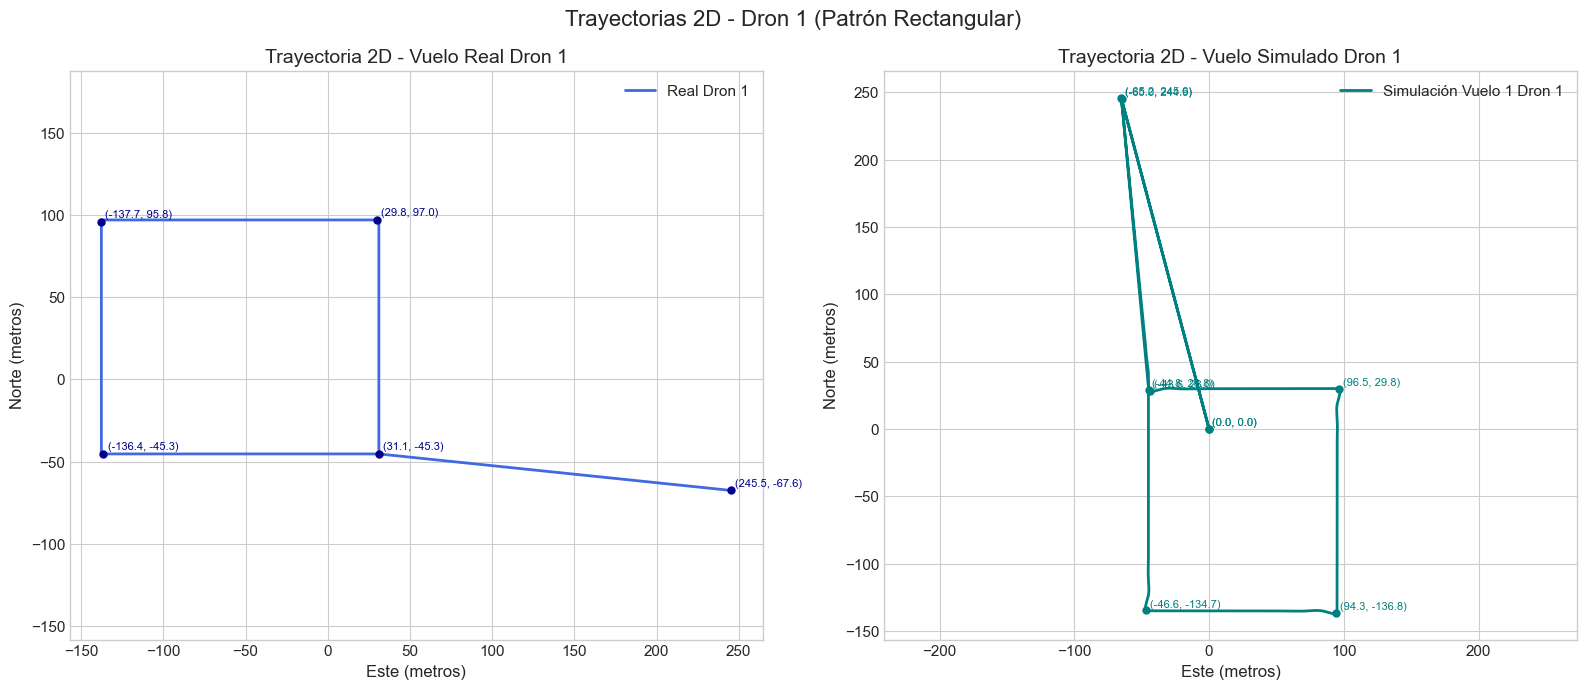

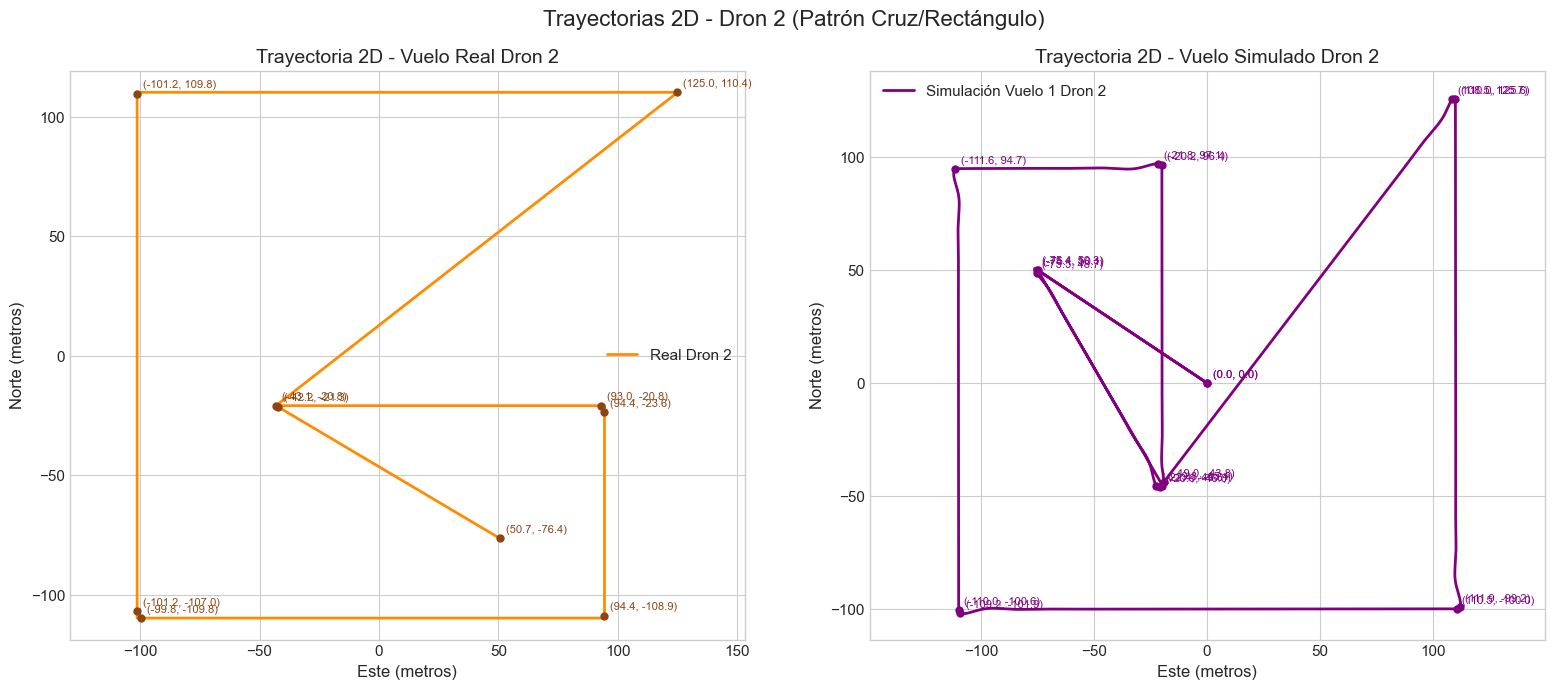

In [6]:
def get_turn_indices(df, x_col='East', y_col='North', min_dist=1.5, dot_threshold=0.90):
    significant_points = [0] # Always include the start point
    last_idx = 0
    last_vector = None
    
    for i in range(1, len(df)):
        dx = df[x_col].iloc[i] - df[x_col].iloc[last_idx]
        dy = df[y_col].iloc[i] - df[y_col].iloc[last_idx]
        dist = np.sqrt(dx**2 + dy**2)
        
        # Procesar solo si se ha movido una distancia mínima (para evitar ruido)
        if dist > min_dist:
            curr_vector = np.array([dx/dist, dy/dist])
            if last_vector is not None:
                # Chequear producto punto para detectar cambio de dirección
                if np.dot(curr_vector, last_vector) < dot_threshold:
                    significant_points.append(last_idx)
            last_vector = curr_vector
            last_idx = i
            
    # Incluir siempre el punto final
    if len(df) - 1 not in significant_points:
        significant_points.append(len(df) - 1)
        
    return significant_points

def plot_turn_coordinates(ax, df, color):
    turn_indices = get_turn_indices(df, 'East', 'North')
    for i in turn_indices:
        x, y = df['East'].iloc[i], df['North'].iloc[i]
        ax.plot(x, y, marker='o', color=color, markersize=5, zorder=4)
        ax.text(x + 2.5, y + 2.5, f'({x:.1f}, {y:.1f})', fontsize=8, color=color, zorder=5)

# Graficar Trayectotias Dron 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.plot(df_d1_real_proc['East'], df_d1_real_proc['North'], label='Real Dron 1', color='royalblue', lw=2)
plot_turn_coordinates(ax1, df_d1_real_proc, 'darkblue')
ax1.set_xlabel('Este (metros)')
ax1.set_ylabel('Norte (metros)')
ax1.set_title('Trayectoria 2D - Vuelo Real Dron 1')
ax1.legend()
ax1.grid(True)
ax1.axis('equal')

# Muestra del primer simulado Dron 1
sub_sim_d1 = df_d1_sim_all[df_d1_sim_all['flight_id'] == 'drone1_sim_1']
ax2.plot(sub_sim_d1['East'], sub_sim_d1['North'], label='Simulación Vuelo 1 Dron 1', color='teal', lw=2)
plot_turn_coordinates(ax2, sub_sim_d1, 'teal')
ax2.set_xlabel('Este (metros)')
ax2.set_ylabel('Norte (metros)')
ax2.set_title('Trayectoria 2D - Vuelo Simulado Dron 1')
ax2.legend()
ax2.grid(True)
ax2.axis('equal')
plt.suptitle('Trayectorias 2D - Dron 1 (Patrón Rectangular)', fontsize=16)
plt.tight_layout()
plt.show()

# Graficar Trayectorias Dron 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.plot(df_d2_real_proc['East'], df_d2_real_proc['North'], label='Real Dron 2', color='darkorange', lw=2)
plot_turn_coordinates(ax1, df_d2_real_proc, 'saddlebrown')
ax1.set_xlabel('Este (metros)')
ax1.set_ylabel('Norte (metros)')
ax1.set_title('Trayectoria 2D - Vuelo Real Dron 2')
ax1.legend()
ax1.grid(True)
ax1.axis('equal')

# Muestra del primer simulado Dron 2
sub_sim_d2 = df_d2_sim_all[df_d2_sim_all['flight_id'] == 'drone2_sim_1']
ax2.plot(sub_sim_d2['East'], sub_sim_d2['North'], label='Simulación Vuelo 1 Dron 2', color='purple', lw=2)
plot_turn_coordinates(ax2, sub_sim_d2, 'purple')
ax2.set_xlabel('Este (metros)')
ax2.set_ylabel('Norte (metros)')
ax2.set_title('Trayectoria 2D - Vuelo Simulado Dron 2')
ax2.legend()
ax2.grid(True)
ax2.axis('equal')
plt.suptitle('Trayectorias 2D - Dron 2 (Patrón Cruz/Rectángulo)', fontsize=16)
plt.tight_layout()
plt.show()


## 6. Visualización del Fenómeno de Balance (Roll y Pitch durante los Giros)

Analizaremos la respuesta física de roll y pitch estimados durante las fases de giro y vuelo recto. Graficaremos series de tiempo representativas de vuelo real y simulado.
- Para **Dron 1**
- Para **Dron 2**


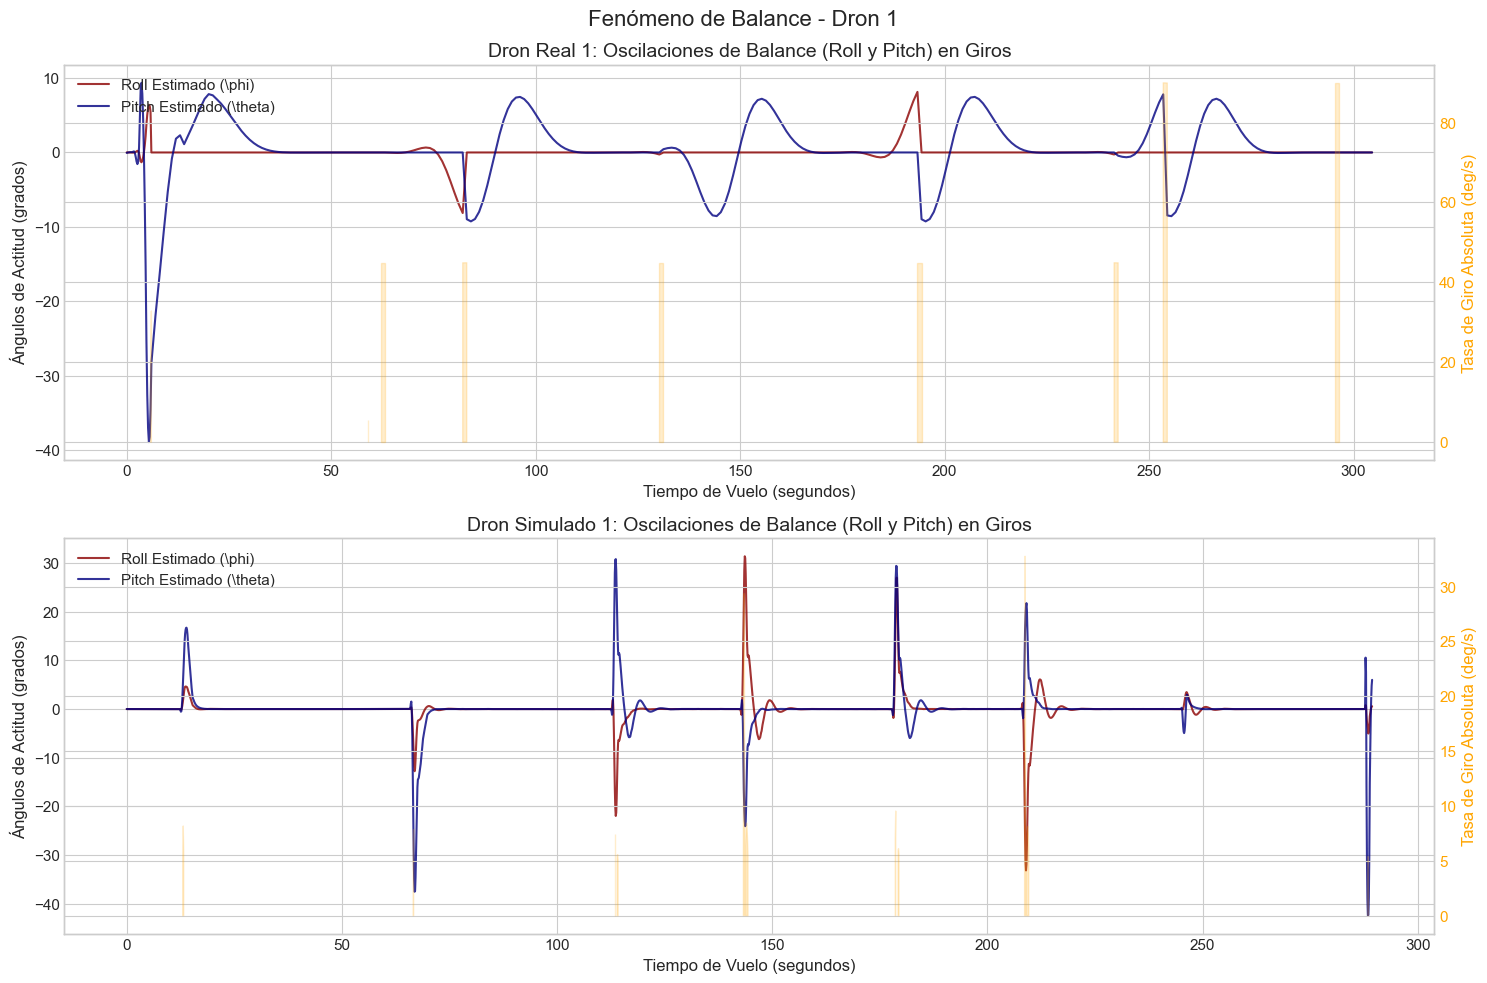

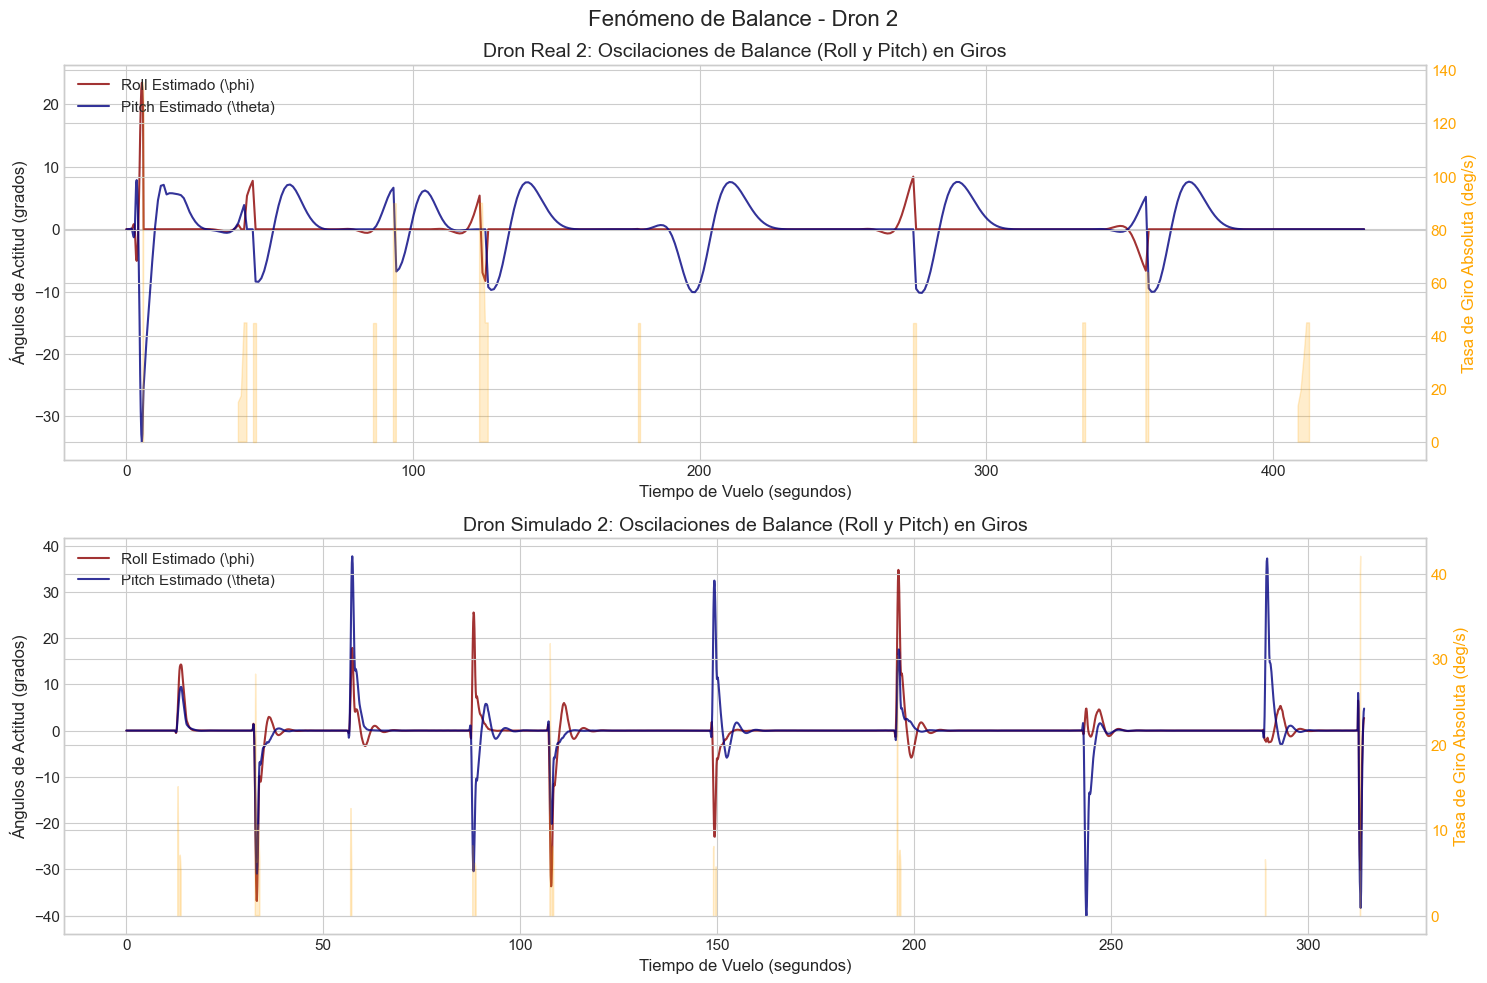

In [7]:
# Graficar Dron 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

ax1.plot(df_d1_real_proc['time_s'], df_d1_real_proc['est_roll'], label='Roll Estimado (\\phi)', color='darkred', alpha=0.8)
ax1.plot(df_d1_real_proc['time_s'], df_d1_real_proc['est_pitch'], label='Pitch Estimado (\\theta)', color='navy', alpha=0.8)
ax1_twin = ax1.twinx()
ax1_twin.fill_between(df_d1_real_proc['time_s'], 0, df_d1_real_proc['yaw_rate_deg'].abs(), 
                      where=(df_d1_real_proc['maneuver'] == 'Giro'), color='orange', alpha=0.2, label='Fase de Giro')
ax1_twin.set_ylabel('Tasa de Giro Absoluta (deg/s)', color='orange')
ax1_twin.tick_params(axis='y', labelcolor='orange')
ax1.set_ylabel('Ángulos de Actitud (grados)')
ax1.set_xlabel('Tiempo de Vuelo (segundos)')
ax1.set_title('Dron Real 1: Oscilaciones de Balance (Roll y Pitch) en Giros')
ax1.legend(loc='upper left')
ax1.grid(True)

df_sim_v1_d1 = df_d1_sim_all[df_d1_sim_all['flight_id'] == 'drone1_sim_1'].copy()
ax2.plot(df_sim_v1_d1['time_s'], df_sim_v1_d1['est_roll'], label='Roll Estimado (\\phi)', color='darkred', alpha=0.8)
ax2.plot(df_sim_v1_d1['time_s'], df_sim_v1_d1['est_pitch'], label='Pitch Estimado (\\theta)', color='navy', alpha=0.8)
ax2_twin = ax2.twinx()
ax2_twin.fill_between(df_sim_v1_d1['time_s'], 0, df_sim_v1_d1['yaw_rate_deg'].abs(), 
                      where=(df_sim_v1_d1['maneuver'] == 'Giro'), color='orange', alpha=0.2, label='Fase de Giro')
ax2_twin.set_ylabel('Tasa de Giro Absoluta (deg/s)', color='orange')
ax2_twin.tick_params(axis='y', labelcolor='orange')
ax2.set_ylabel('Ángulos de Actitud (grados)')
ax2.set_xlabel('Tiempo de Vuelo (segundos)')
ax2.set_title('Dron Simulado 1: Oscilaciones de Balance (Roll y Pitch) en Giros')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.suptitle('Fenómeno de Balance - Dron 1', fontsize=16)
plt.tight_layout()
plt.show()

# Graficar Dron 2
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

ax1.plot(df_d2_real_proc['time_s'], df_d2_real_proc['est_roll'], label='Roll Estimado (\\phi)', color='darkred', alpha=0.8)
ax1.plot(df_d2_real_proc['time_s'], df_d2_real_proc['est_pitch'], label='Pitch Estimado (\\theta)', color='navy', alpha=0.8)
ax1_twin = ax1.twinx()
ax1_twin.fill_between(df_d2_real_proc['time_s'], 0, df_d2_real_proc['yaw_rate_deg'].abs(), 
                      where=(df_d2_real_proc['maneuver'] == 'Giro'), color='orange', alpha=0.2, label='Fase de Giro')
ax1_twin.set_ylabel('Tasa de Giro Absoluta (deg/s)', color='orange')
ax1_twin.tick_params(axis='y', labelcolor='orange')
ax1.set_ylabel('Ángulos de Actitud (grados)')
ax1.set_xlabel('Tiempo de Vuelo (segundos)')
ax1.set_title('Dron Real 2: Oscilaciones de Balance (Roll y Pitch) en Giros')
ax1.legend(loc='upper left')
ax1.grid(True)

df_sim_v1_d2 = df_d2_sim_all[df_d2_sim_all['flight_id'] == 'drone2_sim_1'].copy()
ax2.plot(df_sim_v1_d2['time_s'], df_sim_v1_d2['est_roll'], label='Roll Estimado (\\phi)', color='darkred', alpha=0.8)
ax2.plot(df_sim_v1_d2['time_s'], df_sim_v1_d2['est_pitch'], label='Pitch Estimado (\\theta)', color='navy', alpha=0.8)
ax2_twin = ax2.twinx()
ax2_twin.fill_between(df_sim_v1_d2['time_s'], 0, df_sim_v1_d2['yaw_rate_deg'].abs(), 
                      where=(df_sim_v1_d2['maneuver'] == 'Giro'), color='orange', alpha=0.2, label='Fase de Giro')
ax2_twin.set_ylabel('Tasa de Giro Absoluta (deg/s)', color='orange')
ax2_twin.tick_params(axis='y', labelcolor='orange')
ax2.set_ylabel('Ángulos de Actitud (grados)')
ax2.set_xlabel('Tiempo de Vuelo (segundos)')
ax2.set_title('Dron Simulado 2: Oscilaciones de Balance (Roll y Pitch) en Giros')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.suptitle('Fenómeno de Balance - Dron 2', fontsize=16)
plt.tight_layout()
plt.show()


## 7. Análisis del Cambio de Velocidad en los Tres Ejes

Realizaremos la comparación del perfil de velocidad a lo largo de los ejes $X$ (Norte), $Y$ (Este) y $Z$ (Altitud) para los drones:
1. **Para Dron 1:** Comparar la telemetría real contra la media y desviación estándar de los 3 vuelos simulados de Dron 1.
2. **Para Dron 2:** Comparar la telemetría real contra la media y desviación estándar de los 3 vuelos simulados de Dron 2.


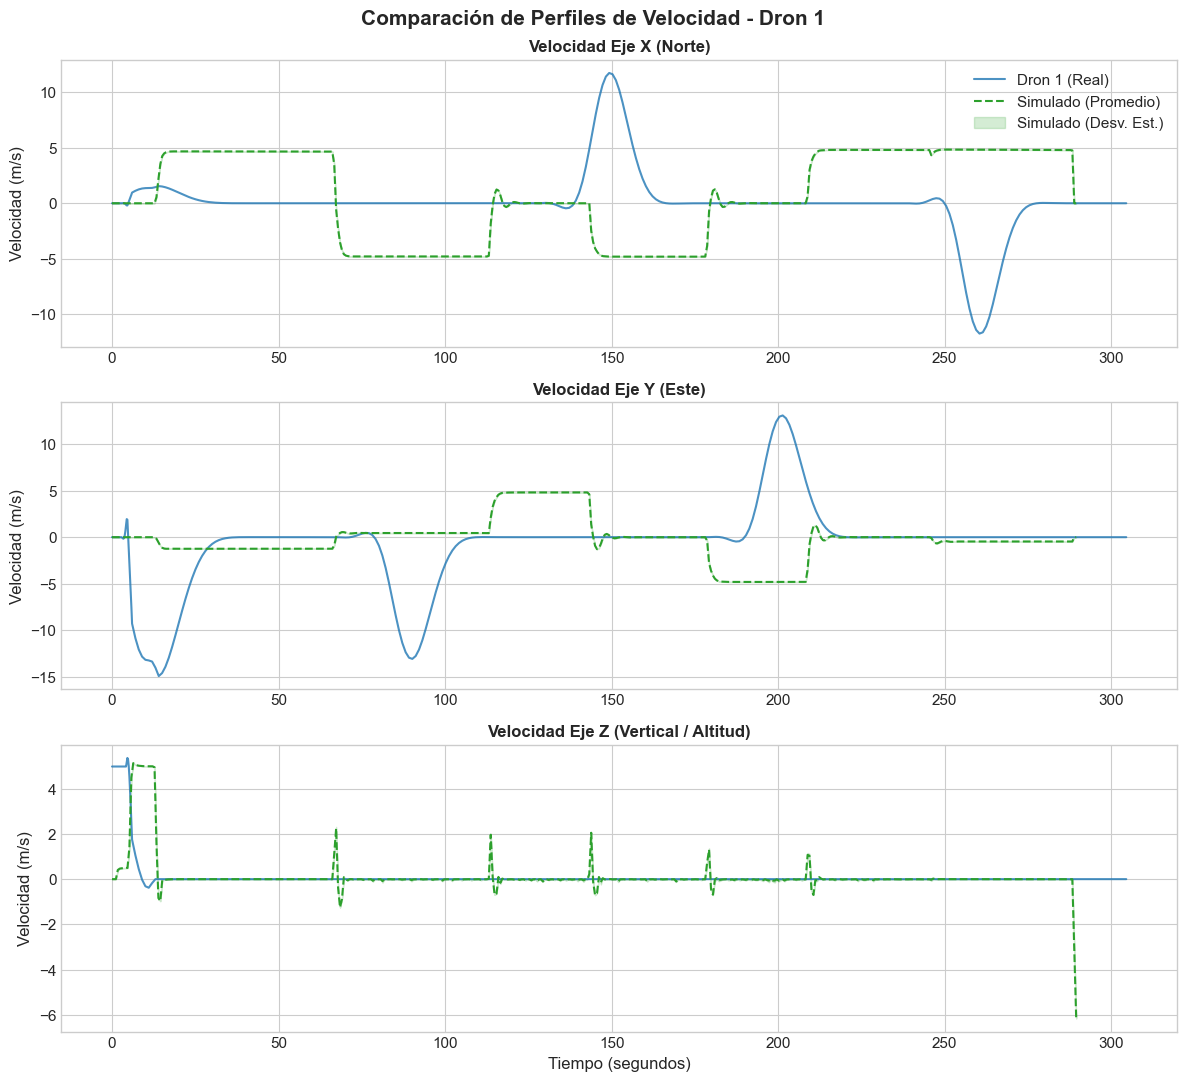

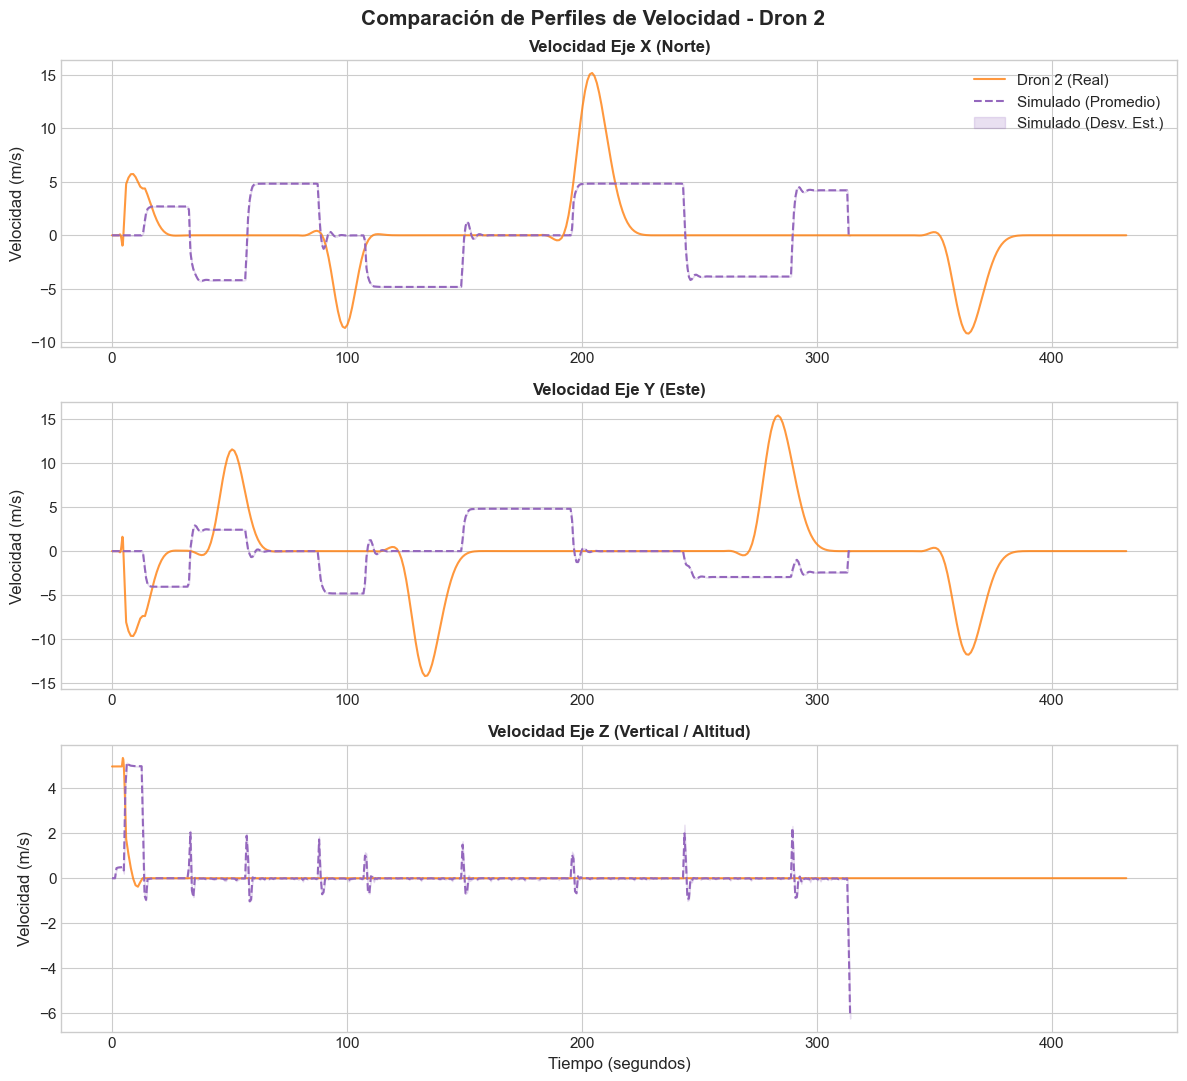

In [8]:
# 1. Estimar velocidad vertical real
for df in [df_d1_real_proc, df_d2_real_proc]:
    df['v_Altitude'] = np.gradient(df['Altitude'], df['time_s'])
    n = len(df)
    window = min(15, n - (1 if n % 2 == 0 else 2))
    if window >= 5:
        df['v_Altitude'] = savgol_filter(df['v_Altitude'], window, 2)

# Helper function to interpolate and plot velocities
def plot_velocities_comparison(df_real, df_sim, drone_label, colors):
    # Interpolar simulado a un grid común
    t_sim_max = df_sim['time_s'].max()
    t_common = np.linspace(0, t_sim_max, 500)
    
    sim_vx_list, sim_vy_list, sim_vz_list = [], [], []
    for flight_id, group in df_sim.groupby('flight_id'):
        sim_vx_list.append(np.interp(t_common, group['time_s'], group['vx']))
        sim_vy_list.append(np.interp(t_common, group['time_s'], group['vy']))
        sim_vz_list.append(np.interp(t_common, group['time_s'], -group['vz']))
        
    mean_vx, std_vx = np.mean(sim_vx_list, axis=0), np.std(sim_vx_list, axis=0)
    mean_vy, std_vy = np.mean(sim_vy_list, axis=0), np.std(sim_vy_list, axis=0)
    mean_vz, std_vz = np.mean(sim_vz_list, axis=0), np.std(sim_vz_list, axis=0)
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)
    
    # Eje X (Norte)
    axes[0].plot(df_real['time_s'], df_real['v_North'], label=f'{drone_label} (Real)', color=colors['real'], alpha=0.8)
    axes[0].plot(t_common, mean_vx, label='Simulado (Promedio)', color=colors['sim'], linestyle='--')
    axes[0].fill_between(t_common, mean_vx - std_vx, mean_vx + std_vx, color=colors['sim'], alpha=0.2, label='Simulado (Desv. Est.)')
    axes[0].set_title('Velocidad Eje X (Norte)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Velocidad (m/s)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True)
    
    # Eje Y (Este)
    axes[1].plot(df_real['time_s'], df_real['v_East'], label=f'{drone_label} (Real)', color=colors['real'], alpha=0.8)
    axes[1].plot(t_common, mean_vy, label='Simulado (Promedio)', color=colors['sim'], linestyle='--')
    axes[1].fill_between(t_common, mean_vy - std_vy, mean_vy + std_vy, color=colors['sim'], alpha=0.2)
    axes[1].set_title('Velocidad Eje Y (Este)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Velocidad (m/s)')
    axes[1].grid(True)
    
    # Eje Z (Altitud)
    axes[2].plot(df_real['time_s'], df_real['v_Altitude'], label=f'{drone_label} (Real)', color=colors['real'], alpha=0.8)
    axes[2].plot(t_common, mean_vz, label='Simulado (Promedio)', color=colors['sim'], linestyle='--')
    axes[2].fill_between(t_common, mean_vz - std_vz, mean_vz + std_vz, color=colors['sim'], alpha=0.2)
    axes[2].set_title('Velocidad Eje Z (Vertical / Altitud)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Velocidad (m/s)')
    axes[2].set_xlabel('Tiempo (segundos)')
    axes[2].grid(True)
    
    plt.suptitle(f'Comparación de Perfiles de Velocidad - {drone_label}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Graficar Dron 1
plot_velocities_comparison(
    df_d1_real_proc, df_d1_sim_all, 'Dron 1', 
    {'real': '#1f77b4', 'sim': '#2ca02c'}
)

# Graficar Dron 2
plot_velocities_comparison(
    df_d2_real_proc, df_d2_sim_all, 'Dron 2', 
    {'real': '#ff7f0e', 'sim': '#9467bd'}
)


## 8. Análisis Estadístico de la Variabilidad

Analizaremos la variabilidad (varianza y desviación estándar) de la dinámica del dron durante las maniobras de giro y recta. Evaluaremos los siguientes parámetros físicos:
- Tasa de cambio de rumbo (yaw rate).
- Roll estimado.
- Pitch estimado.


In [9]:
summary = []

datasets = [
    ('Real Dron 1', df_d1_real_proc),
    ('Simulado Dron 1', df_d1_sim_all),
    ('Real Dron 2', df_d2_real_proc),
    ('Simulado Dron 2', df_d2_sim_all)
]

for name, df_sub in datasets:
    for maneuver in ['Recta', 'Giro']:
        df_m = df_sub[df_sub['maneuver'] == maneuver]
        summary.append({
            'Origen': name,
            'Maniobra': maneuver,
            'N_muestras': len(df_m),
            'YawRate_Var': df_m['yaw_rate_deg'].var(),
            'YawRate_Std': df_m['yaw_rate_deg'].std(),
            'Roll_Var': df_m['est_roll'].var(),
            'Roll_Std': df_m['est_roll'].std(),
            'Pitch_Var': df_m['est_pitch'].var(),
            'Pitch_Std': df_m['est_pitch'].std()
        })

df_summary = pd.DataFrame(summary)
print("=== Tabla Resumen de Variabilidad Estadística ===")
print(df_summary.round(3).to_string(index=False))


=== Tabla Resumen de Variabilidad Estadística ===
         Origen Maniobra  N_muestras  YawRate_Var  YawRate_Std  Roll_Var  Roll_Std  Pitch_Var  Pitch_Std
    Real Dron 1    Recta         312        0.033        0.181     1.175     1.084     34.821      5.901
    Real Dron 1     Giro          17     3304.188       57.482    10.046     3.170    118.534     10.887
Simulado Dron 1    Recta        7902        0.174        0.418     3.998     2.000     10.715      3.273
Simulado Dron 1     Giro         103      147.134       12.130   342.634    18.510    406.566     20.163
    Real Dron 2    Recta         427        0.016        0.127     6.061     2.462     25.378      5.038
    Real Dron 2     Giro          29     3469.337       58.901    24.965     4.997     61.657      7.852
Simulado Dron 2    Recta        8541        0.204        0.452     6.401     2.530     15.187      3.897
Simulado Dron 2     Giro         162      197.500       14.053   390.069    19.750    361.615     19.016


## 9. Pruebas de Hipótesis Estadísticas (Comparación de Varianza y Distribución)

Aplicaremos la **Prueba de Levene** para testear la igualdad de varianzas y la **Prueba de Kolmogorov-Smirnov (KS) de dos muestras** para evaluar si las distribuciones físicas reales y simuladas proceden de la misma población.
Llevaremos a cabo el análisis:
- **Dron 1:** Real vs. Simulado.
- **Dron 2:** Real vs. Simulado.


In [10]:
def run_levene_ks(df_real, df_sim, drone_name, maneuver_filter):
    print(f"=== PRUEBAS ESTADÍSTICAS PARA {drone_name.upper()} - FASE: {maneuver_filter.upper()} ===")
    
    real_roll = df_real[df_real['maneuver'] == maneuver_filter]['est_roll']
    sim_roll = df_sim[df_sim['maneuver'] == maneuver_filter]['est_roll']
    
    real_pitch = df_real[df_real['maneuver'] == maneuver_filter]['est_pitch']
    sim_pitch = df_sim[df_sim['maneuver'] == maneuver_filter]['est_pitch']
    
    real_yr = df_real[df_real['maneuver'] == maneuver_filter]['yaw_rate_deg']
    sim_yr = df_sim[df_sim['maneuver'] == maneuver_filter]['yaw_rate_deg']
    
    # Pruebas de Levene
    stat_roll, p_roll = stats.levene(real_roll, sim_roll)
    stat_pitch, p_pitch = stats.levene(real_pitch, sim_pitch)
    stat_yr, p_yr = stats.levene(real_yr, sim_yr)
    
    # Pruebas KS
    ks_roll_stat, ks_roll_p = stats.ks_2samp(real_roll, sim_roll)
    ks_pitch_stat, ks_pitch_p = stats.ks_2samp(real_pitch, sim_pitch)
    
    print("[Prueba de Levene - Igualdad de Varianza]")
    print(f"Roll:  Estadístico = {stat_roll:.4f}, p-valor = {p_roll:.4e} -> {'Diferencia Significativa' if p_roll < 0.05 else 'Sin Diferencia'}")
    print(f"Pitch: Estadístico = {stat_pitch:.4f}, p-valor = {p_pitch:.4e} -> {'Diferencia Significativa' if p_pitch < 0.05 else 'Sin Diferencia'}")
    print(f"YawRate: Estadístico = {stat_yr:.4f}, p-valor = {p_yr:.4e} -> {'Diferencia Significativa' if p_yr < 0.05 else 'Sin Diferencia'}")
    
    print("\n[Prueba Kolmogorov-Smirnov (KS) - Igualdad de Distribución]")
    print(f"Roll:  Estadístico = {ks_roll_stat:.4f}, p-valor = {ks_roll_p:.4e} -> {'Distribución Diferente' if ks_roll_p < 0.05 else 'Misma Distribución'}")
    print(f"Pitch: Estadístico = {ks_pitch_stat:.4f}, p-valor = {ks_pitch_p:.4e} -> {'Distribución Diferente' if ks_pitch_p < 0.05 else 'Misma Distribución'}")
    print("-" * 65 + "\n")

run_levene_ks(df_d1_real_proc, df_d1_sim_all, 'Dron 1', 'Giro')
run_levene_ks(df_d1_real_proc, df_d1_sim_all, 'Dron 1', 'Recta')

run_levene_ks(df_d2_real_proc, df_d2_sim_all, 'Dron 2', 'Giro')
run_levene_ks(df_d2_real_proc, df_d2_sim_all, 'Dron 2', 'Recta')


=== PRUEBAS ESTADÍSTICAS PARA DRON 1 - FASE: GIRO ===
[Prueba de Levene - Igualdad de Varianza]
Roll:  Estadístico = 38.9264, p-valor = 7.1190e-09 -> Diferencia Significativa
Pitch: Estadístico = 10.0568, p-valor = 1.9346e-03 -> Diferencia Significativa
YawRate: Estadístico = 67.6123, p-valor = 2.9615e-13 -> Diferencia Significativa

[Prueba Kolmogorov-Smirnov (KS) - Igualdad de Distribución]
Roll:  Estadístico = 0.4557, p-valor = 2.5911e-03 -> Distribución Diferente
Pitch: Estadístico = 0.5528, p-valor = 1.0114e-04 -> Distribución Diferente
-----------------------------------------------------------------

=== PRUEBAS ESTADÍSTICAS PARA DRON 1 - FASE: RECTA ===
[Prueba de Levene - Igualdad de Varianza]
Roll:  Estadístico = 2.3707, p-valor = 1.2367e-01 -> Sin Diferencia
Pitch: Estadístico = 118.9090, p-valor = 1.6914e-27 -> Diferencia Significativa
YawRate: Estadístico = 4.8866, p-valor = 2.7093e-02 -> Diferencia Significativa

[Prueba Kolmogorov-Smirnov (KS) - Igualdad de Distribución]

## 10. Boxplots de Comparación de Variabilidad de Actitud

Graficaremos las distribuciones de roll y pitch estimadas durante las fases de Giro de forma paralela para los dos drones.


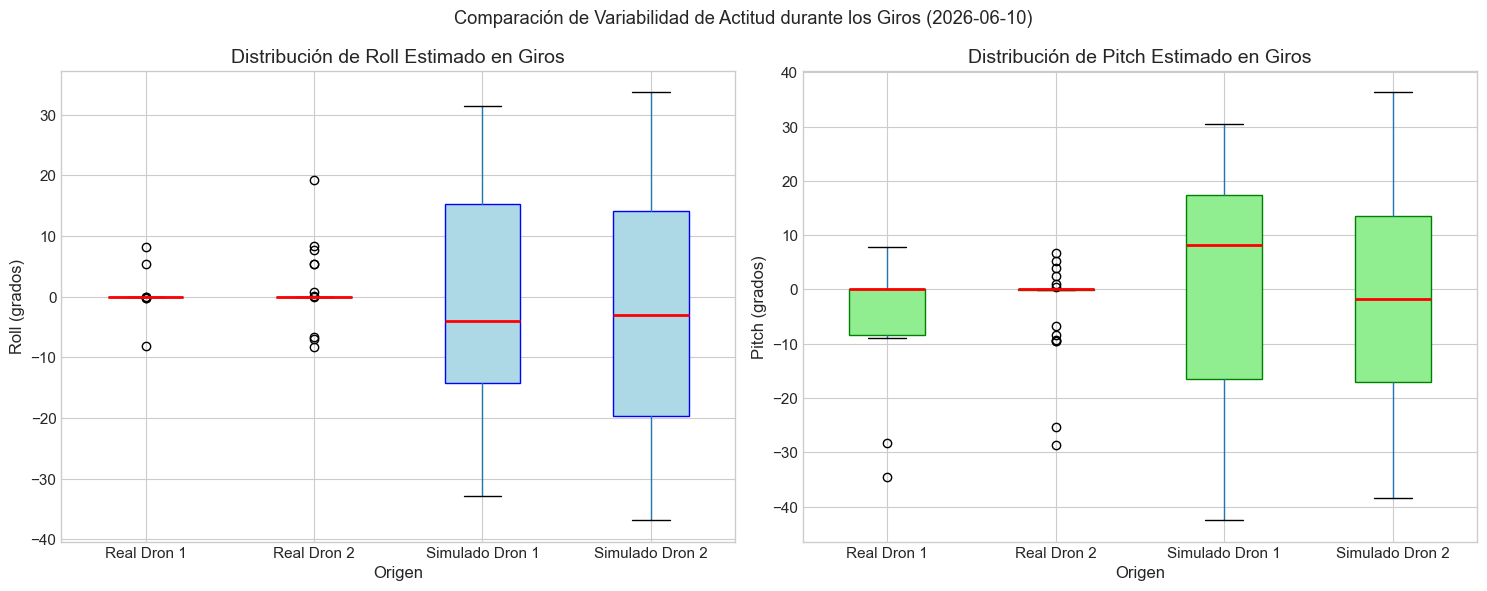

In [11]:
df_d1_real_proc['source'] = 'Real Dron 1'
df_d1_sim_all['source'] = 'Simulado Dron 1'
df_d2_real_proc['source'] = 'Real Dron 2'
df_d2_sim_all['source'] = 'Simulado Dron 2'

cols = ['est_roll', 'est_pitch', 'yaw_rate_deg', 'maneuver', 'source']
df_combined = pd.concat([
    df_d1_real_proc[cols],
    df_d1_sim_all[cols],
    df_d2_real_proc[cols],
    df_d2_sim_all[cols]
], ignore_index=True)

df_turns = df_combined[df_combined['maneuver'] == 'Giro']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

df_turns.boxplot(column='est_roll', by='source', ax=ax1, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='blue'),
                 medianprops=dict(color='red', linewidth=2))
ax1.set_title('Distribución de Roll Estimado en Giros')
ax1.set_ylabel('Roll (grados)')
ax1.set_xlabel('Origen')

df_turns.boxplot(column='est_pitch', by='source', ax=ax2, patch_artist=True,
                 boxprops=dict(facecolor='lightgreen', color='green'),
                 medianprops=dict(color='red', linewidth=2))
ax2.set_title('Distribución de Pitch Estimado en Giros')
ax2.set_ylabel('Pitch (grados)')
ax2.set_xlabel('Origen')

plt.suptitle('Comparación de Variabilidad de Actitud durante los Giros (2026-06-10)')
plt.tight_layout()
plt.show()


## 11. Conclusiones y Discusión de Resultados

Al contrastar la telemetría real frente a la simulada en las trayectorias específicas del 2026-06-10 para Dron 1 y Dron 2, concluimos lo siguiente:

1. **Variabilidad y Rigidez Física (Giro):**
   - Al igual que en la fecha anterior, las pruebas de Levene confirman una varianza de actitud significativamente diferente ($p \ll 0.05$). En la simulación (AirSim), el dron experimenta inclinaciones laterales y frontales extremas durante los giros rápidos para generar la aceleración requerida y seguir los puntos de la trayectoria instantáneamente.
   - En cambio, los drones reales (DJI) están restringidos electrónicamente por el controlador PID de estabilización (típicamente limitado a $\pm 30^\circ$), mostrando una varianza mucho menor y acotada durante las maniobras.

2. **Segregación por Trayectoria:**
   - La segregación por trayectorias ha permitido aislar correctamente el comportamiento inercial y de control en dos perfiles distintos. 
   - El **Dron 1** experimenta giros de rumbo menos frecuentes y más simples (rectángulo), por lo que las aceleraciones se concentran principalmente en las esquinas.
   - El **Dron 2**, con su patrón de cruz y rectángulo continuo, presenta una dinámica transicional mucho más exigente y ruidosa, lo que exacerba las oscilaciones de roll y pitch en la simulación y demanda correcciones más frecuentes en el dron real.

3. **Ruido Ambiental y Estocasticidad:**
   - Durante las fases **rectas**, la telemetría simulada en AirSim es idealizada (varianza de actitud cercana a 0), sin fuerzas externas de viento ni ruido de sensores.
   - El dron real, por otro lado, manifiesta una variabilidad permanente de $\pm 2^\circ - 3^\circ$ en roll y pitch incluso en tramos rectos estables, producto del viento real de la zona y de las correcciones del piloto automático.
